<a href="https://colab.research.google.com/github/linda-bsharat/telco-customer-churn-prediction/blob/main/notebooks/Models_Compare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikeras xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import time
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier

sns.set_theme(style='whitegrid')
print("Ready!")

Ready!


In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/linda-bsharat/telco-customer-churn-prediction/refs/heads/main/data/telco_customer_data_cleaned.csv")
print(df.shape)
df.head()

(67157, 26)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,Churn,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,IsNewCustomer,IsLongTermCustomer,AvgMonthlyCharge,TotalServices
0,1,0,0,1,3.0,1,2,0,0,0,...,205.83,1,False,False,False,True,1,0,68.61,1
1,1,1,1,0,2.0,1,2,1,0,0,...,46.30,0,True,False,False,False,1,0,23.15,2
2,0,0,0,0,42.0,1,2,1,0,1,...,1790.46,1,False,False,True,False,0,0,42.63,4
3,0,0,0,1,40.0,1,2,2,0,0,...,3001.60,0,False,False,True,False,0,0,75.04,2
4,1,1,1,1,17.0,1,1,2,1,0,...,380.46,1,False,False,True,False,0,0,22.38,3


In [3]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

Train: 53,725 | Test: 13,432


In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

def find_best_threshold(y_true, y_prob):
    best_thresh, best_f1 = 0.5, 0.0
    for t in np.arange(0.01, 1.0, 0.01):
        preds = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresh = f1, t
    return best_thresh, best_f1

def plot_threshold(y_true, y_prob, model_name, best_thresh):
    thresholds = np.arange(0.01, 1.0, 0.01)
    precisions, recalls, f1s = [], [], []
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        precisions.append(precision_score(y_true, preds, zero_division=0))
        recalls.append(recall_score(y_true, preds, zero_division=0))
        f1s.append(f1_score(y_true, preds, zero_division=0))
    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, precisions, label='Precision', color='#3498db')
    plt.plot(thresholds, recalls,    label='Recall',    color='#e74c3c')
    plt.plot(thresholds, f1s,        label='F1 Score',  color='#2ecc71', linewidth=2)
    plt.axvline(best_thresh, color='black', linestyle='--', label=f'Best Threshold = {best_thresh:.2f}')
    plt.title(f'Threshold Analysis — {model_name}')
    plt.xlabel('Threshold'); plt.legend(); plt.tight_layout(); plt.show()

def evaluate_model(name, y_true, y_pred, y_prob, color='Blues'):
    print(f'\n{"="*50}\n  {name}\n{"="*50}')
    print(f'  Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'  Precision: {precision_score(y_true, y_pred):.4f}')
    print(f'  Recall   : {recall_score(y_true, y_pred):.4f}')
    print(f'  F1 Score : {f1_score(y_true, y_pred):.4f}')
    print(f'  AUC      : {roc_auc_score(y_true, y_prob):.4f}')
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color,
                xticklabels=['No Churn','Churned'],
                yticklabels=['No Churn','Churned'], ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {name}')
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[1].plot(fpr, tpr, lw=2, label=f'AUC={roc_auc_score(y_true, y_prob):.4f}')
    axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
    axes[1].set_title(f'ROC Curve — {name}'); axes[1].legend()
    plt.tight_layout(); plt.show()

print("Helper functions ready!")

Helper functions ready!


In [5]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

lr_base_cv = cross_validate(lr_pipeline, X, y, cv=cv, scoring=scoring)

print('=== Logistic Regression — Baseline CV ===')
for m in scoring:
    s = lr_base_cv[f'test_{m}']
    print(f'  {m:<12}: {s.mean():.4f} ± {s.std():.4f}')

=== Logistic Regression — Baseline CV ===
  accuracy    : 0.7687 ± 0.0046
  precision   : 0.6978 ± 0.0043
  recall      : 0.8935 ± 0.0044
  f1          : 0.7836 ± 0.0041
  roc_auc     : 0.7899 ± 0.0064


In [6]:
lr_param_grid = {
    'model__C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver':  ['liblinear', 'saga']
}

lr_grid = GridSearchCV(
    Pipeline([('scaler', StandardScaler()),
              ('model', LogisticRegression(max_iter=1000, random_state=42))]),
    param_grid=lr_param_grid, cv=cv, scoring='f1', n_jobs=-1
)
lr_grid.fit(X_train, y_train)

print('Best params:', lr_grid.best_params_)
print(f'Best CV F1 : {lr_grid.best_score_:.4f}')

Best params: {'model__C': 0.001, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV F1 : 0.7834


Best Threshold: 0.30


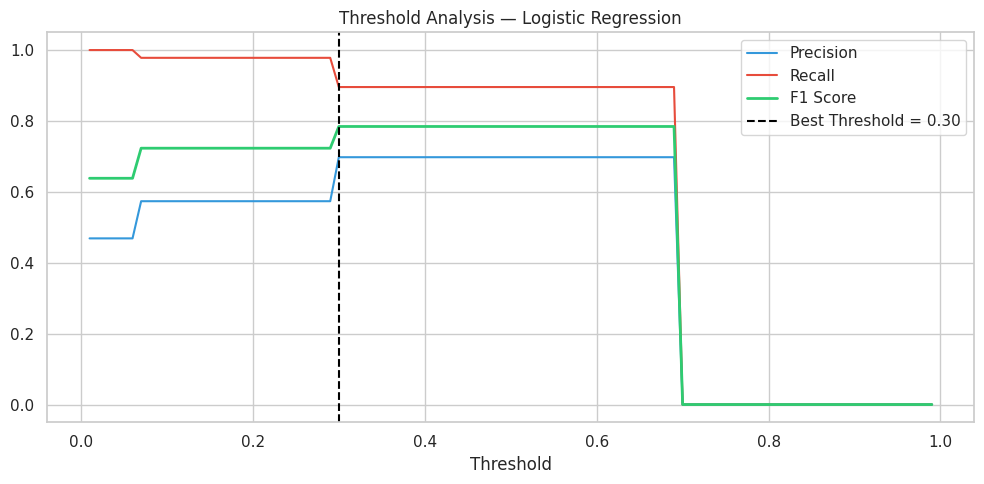


  Logistic Regression (Tuned)
  Accuracy : 0.7692
  Precision: 0.6977
  Recall   : 0.8956
  F1 Score : 0.7844
  AUC      : 0.7881


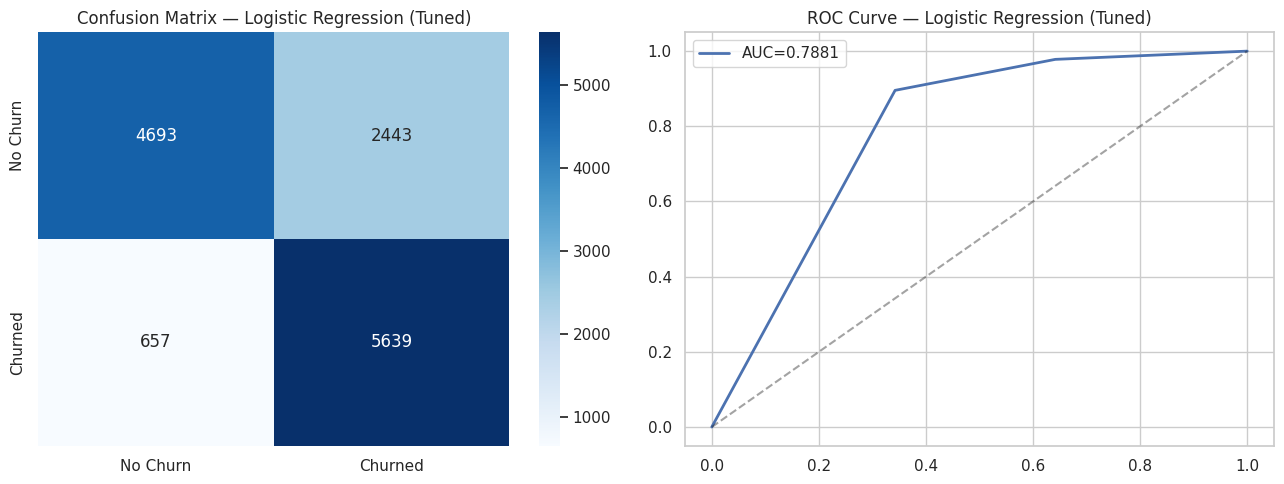

In [7]:
lr_best = lr_grid.best_estimator_
lr_prob  = lr_best.predict_proba(X_test)[:, 1]

lr_thresh, _ = find_best_threshold(y_test, lr_prob)
print(f'Best Threshold: {lr_thresh:.2f}')
plot_threshold(y_test, lr_prob, 'Logistic Regression', lr_thresh)

lr_pred = (lr_prob >= lr_thresh).astype(int)
evaluate_model('Logistic Regression (Tuned)', y_test, lr_pred, lr_prob, color='Blues')

lr_results = {
    'Accuracy': accuracy_score(y_test, lr_pred),
    'Precision': precision_score(y_test, lr_pred),
    'Recall': recall_score(y_test, lr_pred),
    'F1': f1_score(y_test, lr_pred),
    'AUC': roc_auc_score(y_test, lr_prob),
    'Threshold': lr_thresh
}

# Random Forest

In [8]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base_cv = cross_validate(rf_base, X, y, cv=cv, scoring=scoring)

print('=== Random Forest — Baseline CV ===')
for m in scoring:
    s = rf_base_cv[f'test_{m}']
    print(f'  {m:<12}: {s.mean():.4f} ± {s.std():.4f}')

=== Random Forest — Baseline CV ===
  accuracy    : 0.7535 ± 0.0046
  precision   : 0.6965 ± 0.0046
  recall      : 0.8404 ± 0.0042
  f1          : 0.7617 ± 0.0042
  roc_auc     : 0.7876 ± 0.0055


بدء عملية البحث عن أفضل البارامترات... انتظر التقارير بالأسفل:
Fitting 5 folds for each of 20 candidates, totalling 100 fits
------------------------------
تم الانتهاء بنجاح! الوقت المستغرق: 12.37 دقيقة
Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10, 'class_weight': None}
Best CV F1 : 0.7834


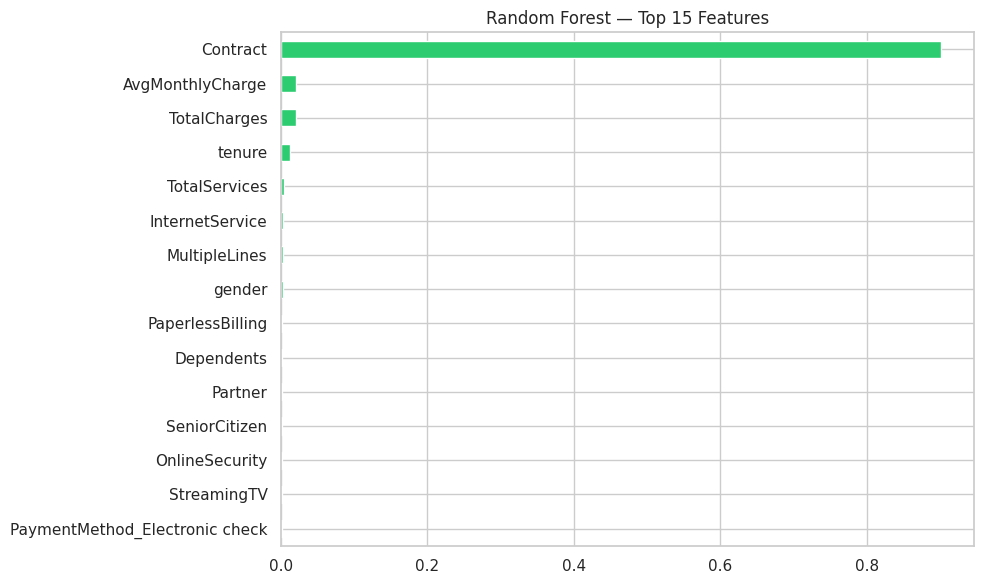

In [9]:
rf_param_dist = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'class_weight'     : [None, 'balanced']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("بدء عملية البحث عن أفضل البارامترات... انتظر التقارير بالأسفل:")
start_time = time.time()

rf_search.fit(X_train, y_train)

end_time = time.time()
duration = (end_time - start_time) / 60

print("-" * 30)
print(f"تم الانتهاء بنجاح! الوقت المستغرق: {duration:.2f} دقيقة")
print('Best params:', rf_search.best_params_)
print(f'Best CV F1 : {rf_search.best_score_:.4f}')

# Feature Importance
rf_best = rf_search.best_estimator_
feat_imp = pd.Series(rf_best.feature_importances_, index=X.columns).nlargest(15).sort_values()
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='#2ecc71')
plt.title('Random Forest — Top 15 Features'); plt.tight_layout(); plt.show()

Best Threshold: 0.34


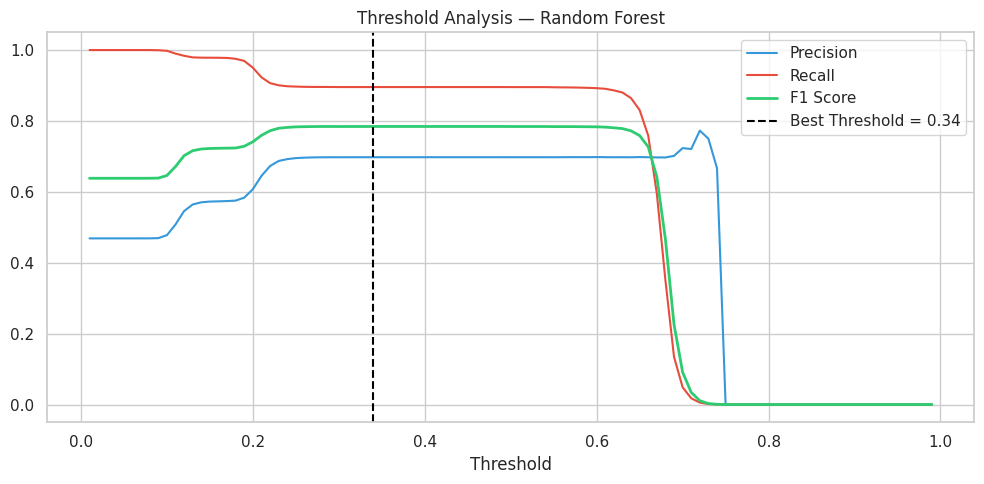


  Random Forest (Tuned)
  Accuracy : 0.7692
  Precision: 0.6977
  Recall   : 0.8956
  F1 Score : 0.7844
  AUC      : 0.7873


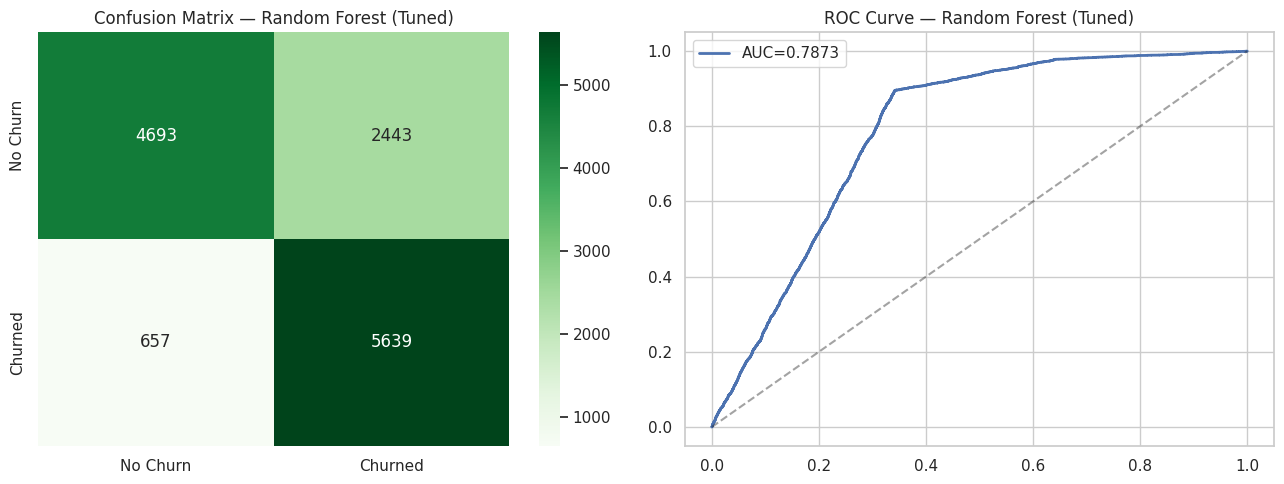

In [10]:
rf_prob   = rf_best.predict_proba(X_test)[:, 1]
rf_thresh, _ = find_best_threshold(y_test, rf_prob)

print(f'Best Threshold: {rf_thresh:.2f}')
plot_threshold(y_test, rf_prob, 'Random Forest', rf_thresh)

rf_pred = (rf_prob >= rf_thresh).astype(int)
evaluate_model('Random Forest (Tuned)', y_test, rf_pred, rf_prob, color='Greens')

rf_results = {
    'Accuracy': accuracy_score(y_test, rf_pred),
    'Precision': precision_score(y_test, rf_pred),
    'Recall': recall_score(y_test, rf_pred),
    'F1': f1_score(y_test, rf_pred),
    'AUC': roc_auc_score(y_test, rf_prob),
    'Threshold': rf_thresh
}

In [11]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / pos
print(f'scale_pos_weight = {scale_pos:.2f}')

xgb_base = XGBClassifier(scale_pos_weight=scale_pos, eval_metric='logloss',
                          random_state=42, verbosity=0)
xgb_base_cv = cross_validate(xgb_base, X, y, cv=cv, scoring=scoring)

print('\n=== XGBoost — Baseline CV ===')
for m in scoring:
    s = xgb_base_cv[f'test_{m}']
    print(f'  {m:<12}: {s.mean():.4f} ± {s.std():.4f}')

scale_pos_weight = 1.13

=== XGBoost — Baseline CV ===
  accuracy    : 0.7646 ± 0.0043
  precision   : 0.6971 ± 0.0042
  recall      : 0.8805 ± 0.0044
  f1          : 0.7781 ± 0.0038
  roc_auc     : 0.7901 ± 0.0061


Best params: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.8}
Best CV F1 : 0.7834


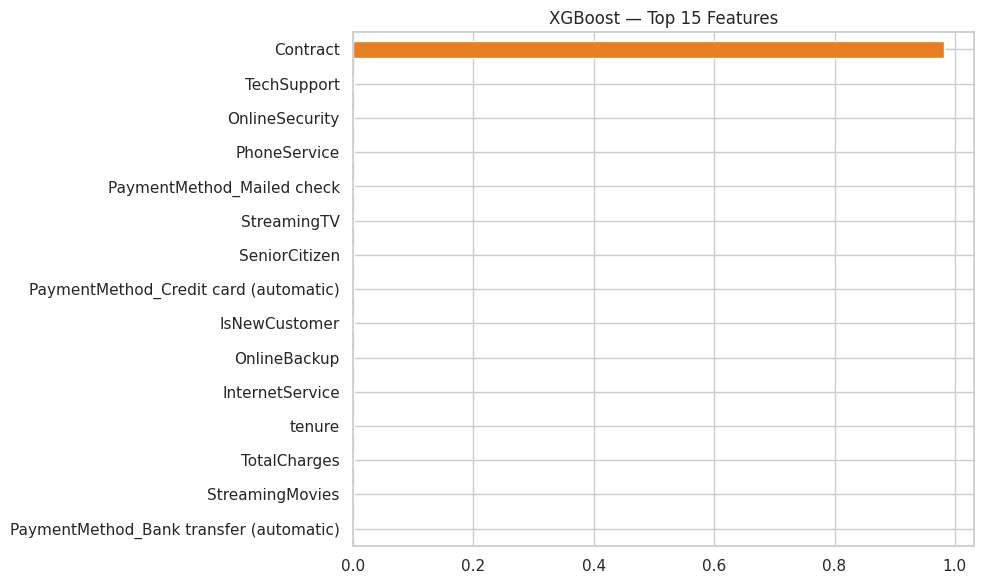

In [12]:
xgb_param_dist = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma'           : [0, 0.1, 0.3],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos, eval_metric='logloss',
                  random_state=42, verbosity=0),
    param_distributions=xgb_param_dist,
    n_iter=20, cv=cv, scoring='f1', n_jobs=-1, random_state=42
)
xgb_search.fit(X_train, y_train)

print('Best params:', xgb_search.best_params_)
print(f'Best CV F1 : {xgb_search.best_score_:.4f}')

# Feature Importance
xgb_best = xgb_search.best_estimator_
xgb_feat = pd.Series(xgb_best.feature_importances_, index=X.columns).nlargest(15).sort_values()
plt.figure(figsize=(10, 6))
xgb_feat.plot(kind='barh', color='#e67e22')
plt.title('XGBoost — Top 15 Features'); plt.tight_layout(); plt.show()

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_weight_dict = {0: cw[0], 1: cw[1]}

def build_nn():
    m = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        BatchNormalization(), Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(), Dropout(0.3),
        Dense(32, activation='relu'), Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return m

nn_model = build_nn()

history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=100, batch_size=256, validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ],
    verbose=1
)

Epoch 1/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6959 - loss: 0.5941 - val_accuracy: 0.7694 - val_loss: 0.5364 - learning_rate: 0.0010
Epoch 2/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7475 - loss: 0.5391 - val_accuracy: 0.7717 - val_loss: 0.5130 - learning_rate: 0.0010
Epoch 3/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7611 - loss: 0.5257 - val_accuracy: 0.7720 - val_loss: 0.5077 - learning_rate: 0.0010
Epoch 4/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7645 - loss: 0.5216 - val_accuracy: 0.7720 - val_loss: 0.5084 - learning_rate: 0.0010
Epoch 5/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7668 - loss: 0.5174 - val_accuracy: 0.7720 - val_loss: 0.5062 - learning_rate: 0.0010
Epoch 6/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7672 - loss: 0.5155 - val_accuracy: 0.7720 - val_loss: 0.5065 - learning_rate: 0.0010
Epoch 7/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7673 - loss: 0

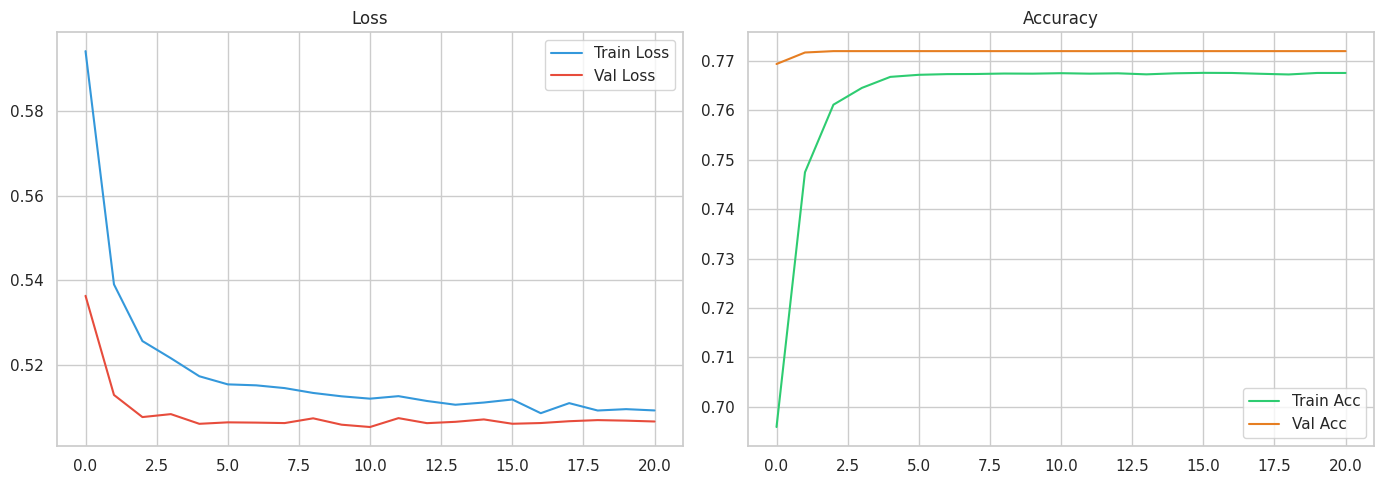

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'],     label='Train Loss', color='#3498db')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#e74c3c')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc', color='#2ecc71')
axes[1].plot(history.history['val_accuracy'], label='Val Acc',   color='#e67e22')
axes[1].set_title('Accuracy'); axes[1].legend()

plt.tight_layout(); plt.show()

420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Best Threshold: 0.64


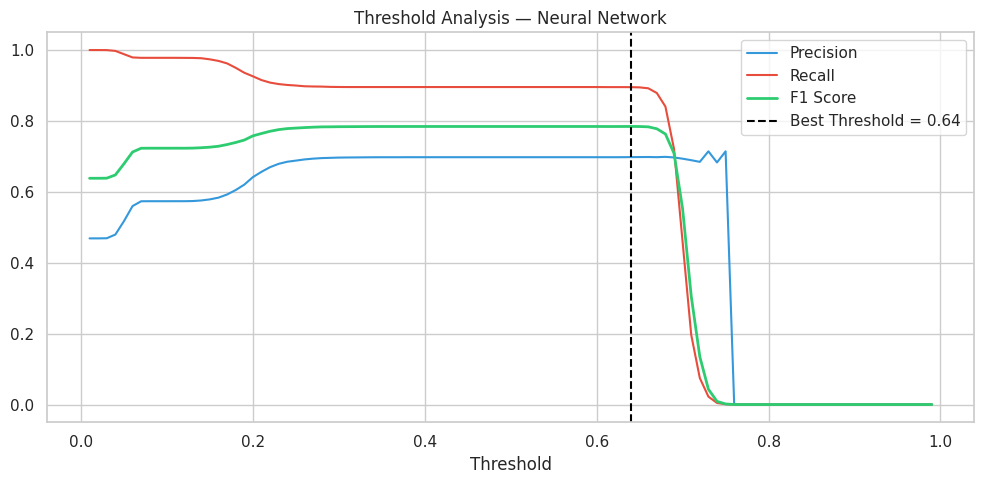


  Neural Network (Tuned)
  Accuracy : 0.7694
  Precision: 0.6980
  Recall   : 0.8953
  F1 Score : 0.7844
  AUC      : 0.7860


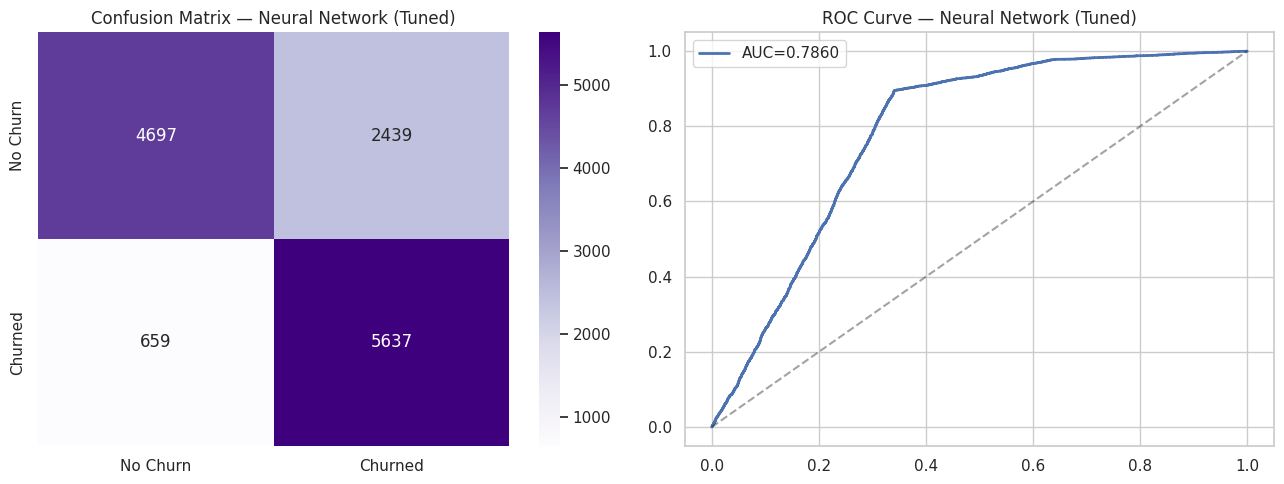

In [15]:
nn_prob  = nn_model.predict(X_test_scaled).flatten()
nn_thresh, _ = find_best_threshold(y_test, nn_prob)

print(f'Best Threshold: {nn_thresh:.2f}')
plot_threshold(y_test, nn_prob, 'Neural Network', nn_thresh)

nn_pred = (nn_prob >= nn_thresh).astype(int)
evaluate_model('Neural Network (Tuned)', y_test, nn_pred, nn_prob, color='Purples')

nn_results = {
    'Accuracy': accuracy_score(y_test, nn_pred),
    'Precision': precision_score(y_test, nn_pred),
    'Recall': recall_score(y_test, nn_pred),
    'F1': f1_score(y_test, nn_pred),
    'AUC': roc_auc_score(y_test, nn_prob),
    'Threshold': nn_thresh
}

                     Accuracy  Precision  Recall      F1     AUC  Threshold
Logistic Regression    0.7692     0.6977  0.8956  0.7844  0.7881       0.30
Random Forest          0.7692     0.6977  0.8956  0.7844  0.7873       0.34
XGBoost                0.7692     0.6977  0.8956  0.7844  0.7866       0.39
Neural Network         0.7694     0.6980  0.8953  0.7844  0.7860       0.64


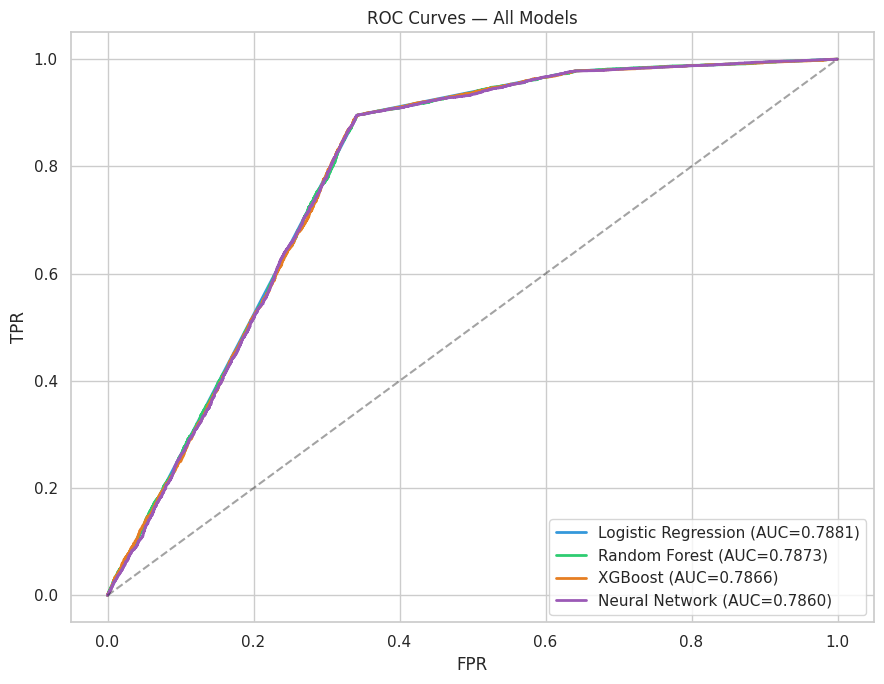

In [17]:
xgb_prob   = xgb_best.predict_proba(X_test)[:, 1]
xgb_thresh, _ = find_best_threshold(y_test, xgb_prob)

xgb_pred = (xgb_prob >= xgb_thresh).astype(int)

xgb_results = {
    'Accuracy': accuracy_score(y_test, xgb_pred),
    'Precision': precision_score(y_test, xgb_pred),
    'Recall': recall_score(y_test, xgb_pred),
    'F1': f1_score(y_test, xgb_pred),
    'AUC': roc_auc_score(y_test, xgb_prob),
    'Threshold': xgb_thresh
}

comparison = pd.DataFrame({
    'Logistic Regression': lr_results,
    'Random Forest'      : rf_results,
    'XGBoost'            : xgb_results,
    'Neural Network'     : nn_results,
}).T.round(4)

print(comparison)

# ROC Curves
plt.figure(figsize=(9, 7))
for name, prob, color in [
    ('Logistic Regression', lr_prob,  '#3498db'),
    ('Random Forest',       rf_prob,  '#2ecc71'),
    ('XGBoost',             xgb_prob, '#e67e22'),
    ('Neural Network',      nn_prob,  '#9b59b6'),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={roc_auc_score(y_test, prob):.4f})')

plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.title('ROC Curves — All Models'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.legend(); plt.tight_layout(); plt.show()